In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import statsmodels.api as sm

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (10, 5)


In [47]:
# Load the 4 raw tables (adjust paths if this notebook lives elsewhere)
transactions = pd.read_csv("sales_transactions.csv", parse_dates=["transaction_date"])
customers = pd.read_csv("customers.csv", parse_dates=["customer_since"])
products = pd.read_csv("products.csv")
campaigns = pd.read_csv("campaigns.csv", parse_dates=["start_date", "end_date"])

customers["business_size"] = customers["business_size"].fillna("Individuals").replace(["N/A", "NA"], "Individuals")

master = transactions.merge(customers, on="customer_id", how="left")
master = master.merge(products, on="product_id", how="left", suffixes=("", "_product"))

master["year_month"] = master["transaction_date"].dt.to_period("M").dt.to_timestamp()
master["year"] = master["transaction_date"].dt.year

# margin_pct is needed throughout both Module 3 and Module 4 analysis below
master["margin_pct"] = 100 * master["gross_margin"] / master["net_revenue"]

print("Master shape:", master.shape)
print("Date range:", master.transaction_date.min().date(), "to", master.transaction_date.max().date())
master.head()


Master shape: (12922, 29)
Date range: 2023-01-01 to 2024-12-31


,transaction_id,transaction_date,customer_id,product_id,branch_id,channel,quantity,unit_price,discount_percentage,gross_revenue,...,business_size,product_name,category,standard_price,cost_price,margin_percentage,active_status,year_month,year,margin_pct
0,T100001,2023-01-01,C1107,P109,BR-Central,Branch,1,221.65,5,221.65,...,Individuals,Beauty Blue 10,Beauty & Personal Care,221.65,169.04,23.74,Active,2023-01-01,2023,19.72
1,T100002,2023-01-01,C1014,P108,BR-North,Online,2,159.08,0,318.16,...,Small,Apparel Since 9,Apparel,159.08,110.17,30.74,Active,2023-01-01,2023,30.75
2,T100003,2023-01-01,C1084,P121,BR-West,Online,4,26.85,5,107.40,...,Individuals,Beauty Early 22,Beauty & Personal Care,26.85,15.50,42.28,Active,2023-01-01,2023,39.23
3,T100004,2023-01-01,C1104,P100,BR-South,Dealer,1,193.52,5,193.52,...,Individuals,Electronics Purpose 1,Electronics,193.52,109.30,43.52,Active,2023-01-01,2023,40.55
4,T100005,2023-01-01,C1022,P129,BR-West,Online,2,32.16,15,64.32,...,Individuals,Office Science 30,Office Supplies,32.16,24.20,24.76,Discontinued,2023-01-01,2023,11.47


## Module 3 — Product and Channel Revenue Analysis

Revenue contribution by category:


,category,net_revenue,gross_margin,transactions,units_sold,revenue_share_pct,margin_pct
3,Home & Living,"1,150,804.71","303,635.35",2231,4320,21.55,26.38
2,Electronics,"1,074,889.14","233,326.51",2231,4421,20.13,21.71
0,Apparel,"914,525.46","230,835.88",2197,4477,17.13,25.24
1,Beauty & Personal Care,"749,341.16","56,579.16",2181,4444,14.03,7.55
4,Office Supplies,"746,590.69","229,587.04",2014,4020,13.98,30.75
5,Sports & Outdoors,"703,468.38","143,307.77",2068,4169,13.17,20.37


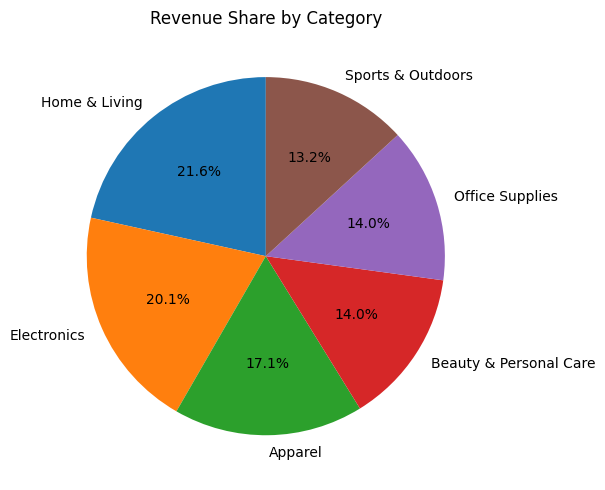

In [48]:
# --- 3.1 Category contribution (EDA) ---
category_summary = master.groupby("category").agg(
    net_revenue=("net_revenue", "sum"),
    gross_margin=("gross_margin", "sum"),
    transactions=("transaction_id", "nunique"),
    units_sold=("quantity", "sum"),
).reset_index()
category_summary["revenue_share_pct"] = round(100 * category_summary["net_revenue"] / category_summary["net_revenue"].sum(), 2)
category_summary["margin_pct"] = round(100 * category_summary["gross_margin"] / category_summary["net_revenue"], 2)
category_summary = category_summary.sort_values("net_revenue", ascending=False)

print("Revenue contribution by category:")
display(category_summary)

fig, ax = plt.subplots()
ax.pie(category_summary["net_revenue"], labels=category_summary["category"], autopct="%1.1f%%", startangle=90)
ax.set_title("Revenue Share by Category")
plt.tight_layout()
plt.show()


channel,Branch,Dealer,Direct Sales,Online,Partner
category,,,,,
Apparel,246301.080000,141614.000000,140485.500000,310653.980000,75470.900000
Beauty & Personal Care,212538.780000,113866.800000,101644.070000,242810.000000,78481.510000
Electronics,250314.600000,168689.010000,149743.830000,398177.190000,107964.510000
Home & Living,318712.250000,169951.910000,156650.930000,388192.560000,117297.060000
Office Supplies,217171.790000,95284.460000,113116.030000,247020.280000,73998.130000
Sports & Outdoors,177145.320000,101726.370000,99117.370000,240822.960000,84656.360000


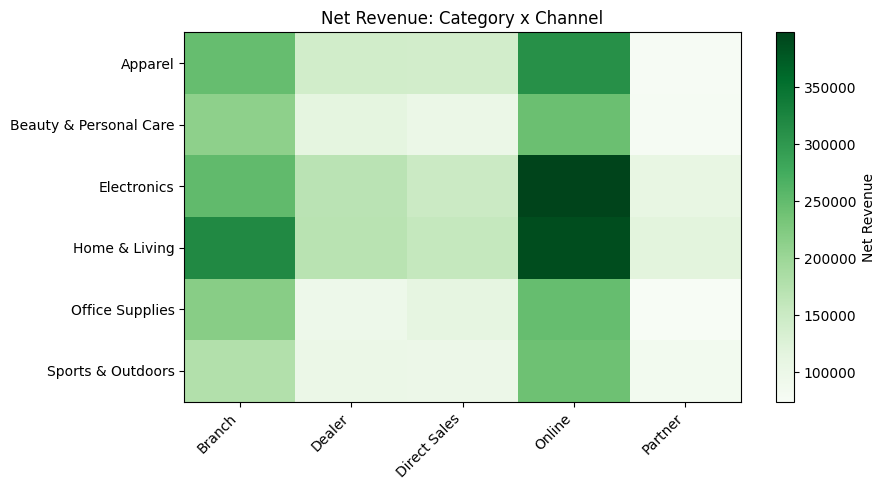

In [49]:
# --- 3.2 Category x Channel cross-tabulation (EDA) ---
cat_channel_pivot = pd.crosstab(master["category"], master["channel"], values=master["net_revenue"], aggfunc="sum").fillna(0)
display(cat_channel_pivot.style.background_gradient(cmap="Greens", axis=None))

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(cat_channel_pivot.values, cmap="Greens", aspect="auto")
ax.set_xticks(range(len(cat_channel_pivot.columns)))
ax.set_xticklabels(cat_channel_pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(cat_channel_pivot.index)))
ax.set_yticklabels(cat_channel_pivot.index)
ax.set_title("Net Revenue: Category x Channel")
fig.colorbar(im, ax=ax, label="Net Revenue")
plt.tight_layout()
plt.show()


In [50]:
# --- 3.3 Top products by revenue, quantity, and margin (EDA) ---
prod_agg = master.groupby(["product_id", "product_name", "category", "active_status"]).agg(
    net_revenue=("net_revenue", "sum"),
    gross_margin=("gross_margin", "sum"),
    units_sold=("quantity", "sum"),
    transactions=("transaction_id", "nunique"),
).reset_index()
prod_agg["margin_pct"] = round(100 * prod_agg["gross_margin"] / prod_agg["net_revenue"], 2)

print("Top 5 products by revenue:")
display(prod_agg.sort_values("net_revenue", ascending=False).head(5))

print("\nTop 5 products by units sold:")
display(prod_agg.sort_values("units_sold", ascending=False).head(5))


Top 5 products by revenue:


,product_id,product_name,category,active_status,net_revenue,gross_margin,units_sold,transactions,margin_pct
17,P117,Office Almost 18,Office Supplies,Active,"452,237.67","158,434.16",1001,469,35.03
25,P125,Home Option 26,Home & Living,Active,"426,645.29","146,584.74",935,461,34.36
26,P126,Apparel Decide 27,Apparel,Active,"402,619.60","153,980.83",909,429,38.24
6,P106,Electronics Dog 7,Electronics,Active,"378,491.90","62,388.32",962,451,16.48
1,P101,Home Brother 2,Home & Living,Active,"331,166.88","95,870.56",952,471,28.95



Top 5 products by units sold:


,product_id,product_name,category,active_status,net_revenue,gross_margin,units_sold,transactions,margin_pct
17,P117,Office Almost 18,Office Supplies,Active,"452,237.67","158,434.16",1001,469,35.03
16,P116,Sports Knowledge 17,Sports & Outdoors,Active,"39,126.38","15,754.22",987,475,40.26
27,P127,Beauty Sense 28,Beauty & Personal Care,Active,"278,429.18","6,067.02",973,470,2.18
6,P106,Electronics Dog 7,Electronics,Active,"378,491.90","62,388.32",962,451,16.48
1,P101,Home Brother 2,Home & Living,Active,"331,166.88","95,870.56",952,471,28.95


In [51]:
# --- 3.4 High-revenue, low-margin products (statistical flagging) ---
# Flags products sitting in the top half of revenue but with thin margin (<10%).
# This is the "high revenue, low profitability" pattern referenced in the data dictionary.
revenue_median = prod_agg["net_revenue"].median()
low_margin_threshold = 10.0

high_rev_low_margin = prod_agg[
    (prod_agg["net_revenue"] >= revenue_median) & (prod_agg["margin_pct"] < low_margin_threshold)
].sort_values("net_revenue", ascending=False)

print(f"{len(high_rev_low_margin)} product(s) flagged as high-revenue / low-margin (margin < {low_margin_threshold}%):")
display(high_rev_low_margin[["product_id", "product_name", "category", "net_revenue", "margin_pct"]])


2 product(s) flagged as high-revenue / low-margin (margin < 10.0%):


,product_id,product_name,category,net_revenue,margin_pct
27,P127,Beauty Sense 28,Beauty & Personal Care,"278,429.18",2.18
15,P115,Beauty Performance 16,Beauty & Personal Care,"234,590.55",-1.90


16 products (53.3% of the catalog) generate ~80% of total revenue.


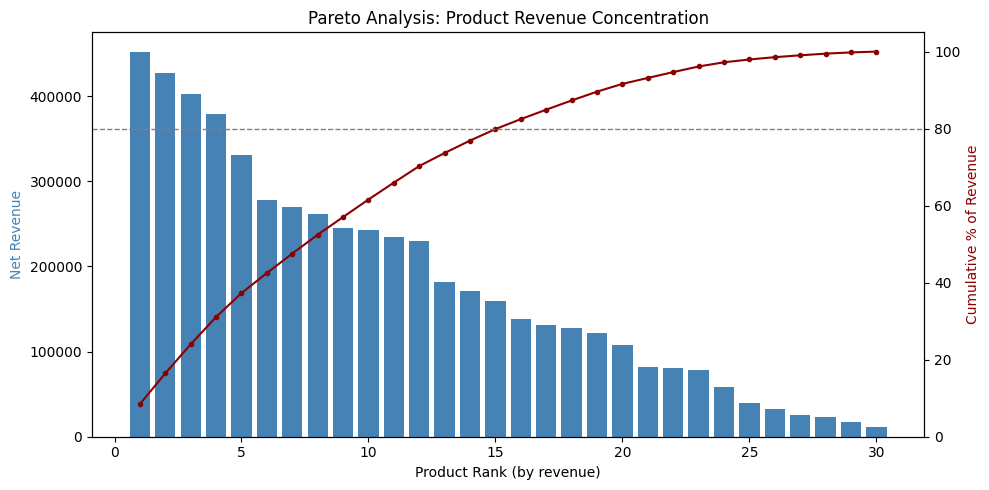

In [52]:
# --- 3.5 Pareto (80/20) analysis with cumulative curve (EDA + statistical) ---
prod_rev = prod_agg.sort_values("net_revenue", ascending=False).reset_index(drop=True)
prod_rev["cumulative_pct"] = 100 * prod_rev["net_revenue"].cumsum() / prod_rev["net_revenue"].sum()
prod_rev["product_rank"] = range(1, len(prod_rev) + 1)

n_products_for_80 = (prod_rev["cumulative_pct"] <= 80).sum() + 1
pct_of_catalog = round(100 * n_products_for_80 / len(prod_rev), 1)
print(f"{n_products_for_80} products ({pct_of_catalog}% of the catalog) generate ~80% of total revenue.")

fig, ax1 = plt.subplots()
ax1.bar(prod_rev["product_rank"], prod_rev["net_revenue"], color="steelblue")
ax1.set_xlabel("Product Rank (by revenue)")
ax1.set_ylabel("Net Revenue", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(prod_rev["product_rank"], prod_rev["cumulative_pct"], color="darkred", marker="o", markersize=3)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative % of Revenue", color="darkred")
ax2.set_ylim(0, 105)

plt.title("Pareto Analysis: Product Revenue Concentration")
plt.tight_layout()
plt.show()


In [53]:
channel_summary = master.groupby("channel").agg(
    net_revenue=("net_revenue", "sum"),
    gross_margin=("gross_margin", "sum"),
    transactions=("transaction_id", "nunique"),
    units_sold=("quantity", "sum"),
).reset_index()
channel_summary["margin_pct"] = round(100 * channel_summary["gross_margin"] / channel_summary["net_revenue"], 2)
channel_summary["avg_order_value"] = round(channel_summary["net_revenue"] / channel_summary["transactions"], 2)
channel_summary = channel_summary.sort_values("net_revenue", ascending=False)

# --- 3.6b Best and weakest performing channels (explicit call-out) ---
best_by_revenue = channel_summary.iloc[0]
weakest_by_revenue = channel_summary.iloc[-1]
best_by_margin = channel_summary.sort_values("margin_pct", ascending=False).iloc[0]
weakest_by_margin = channel_summary.sort_values("margin_pct", ascending=False).iloc[-1]

print(f"Best channel by revenue: {best_by_revenue['channel']} ({best_by_revenue['net_revenue']:,.0f})")
print(f"Weakest channel by revenue: {weakest_by_revenue['channel']} ({weakest_by_revenue['net_revenue']:,.0f})")
print(f"\nBest channel by margin %: {best_by_margin['channel']} ({best_by_margin['margin_pct']} دستي}})")
print(f"Weakest channel by margin %: {weakest_by_margin['channel']} ({weakest_by_margin['margin_pct']} دستي}})")

if best_by_revenue["channel"] != best_by_margin["channel"]:
    print(f"\nNote: '{best_by_revenue['channel']}' leads on revenue but not on margin — "
          f"a candidate for cost/commission review rather than a pure growth channel.")


Best channel by revenue: Online (1,827,677)
Weakest channel by revenue: Partner (537,868)

Best channel by margin %: Branch (22.98 دستي})
Weakest channel by margin %: Dealer (21.94 دستي})

Note: 'Online' leads on revenue but not on margin — a candidate for cost/commission review rather than a pure growth channel.


Channel comparison:


,channel,net_revenue,gross_margin,transactions,units_sold,margin_pct,avg_order_value
3,Online,"1,827,676.97","405,274.88",4429,8779,22.17,412.66
0,Branch,"1,422,183.82","326,813.15",3360,6845,22.98,423.27
1,Dealer,"791,132.55","173,575.89",1956,3883,21.94,404.46
2,Direct Sales,"760,757.73","170,388.48",1890,3721,22.40,402.52
4,Partner,"537,868.47","121,219.31",1287,2623,22.54,417.92


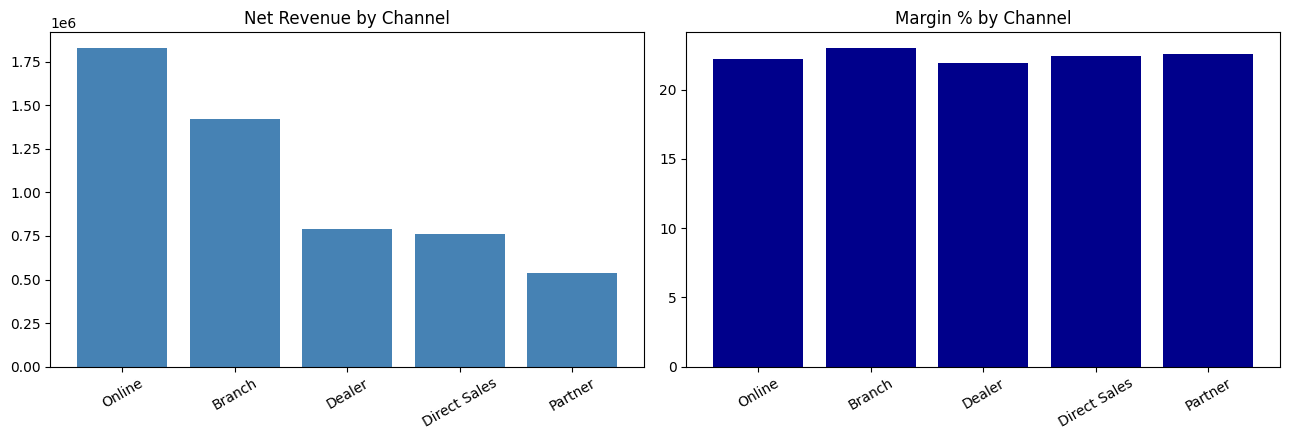

In [55]:
# --- 3.6 Channel comparison (EDA) ---
channel_summary = master.groupby("channel").agg(
    net_revenue=("net_revenue", "sum"),
    gross_margin=("gross_margin", "sum"),
    transactions=("transaction_id", "nunique"),
    units_sold=("quantity", "sum"),
).reset_index()
channel_summary["margin_pct"] = round(100 * channel_summary["gross_margin"] / channel_summary["net_revenue"], 2)
channel_summary["avg_order_value"] = round(channel_summary["net_revenue"] / channel_summary["transactions"], 2)
channel_summary = channel_summary.sort_values("net_revenue", ascending=False)

print("Channel comparison:")
display(channel_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(channel_summary["channel"], channel_summary["net_revenue"], color="steelblue")
axes[0].set_title("Net Revenue by Channel")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(channel_summary["channel"], channel_summary["margin_pct"], color="darkblue")
axes[1].set_title("Margin % by Channel")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


Branch ranking:


,branch_id,net_revenue,gross_margin,transactions,margin_pct
2,BR-North,"1,353,483.71","302,675.21",3283,22.36
1,BR-East,"1,107,221.67","249,448.45",2650,22.53
4,BR-West,"1,083,634.69","248,473.78",2597,22.93
3,BR-South,"1,038,678.58","228,299.91",2513,21.98
0,BR-Central,"756,600.89","168,374.36",1879,22.25


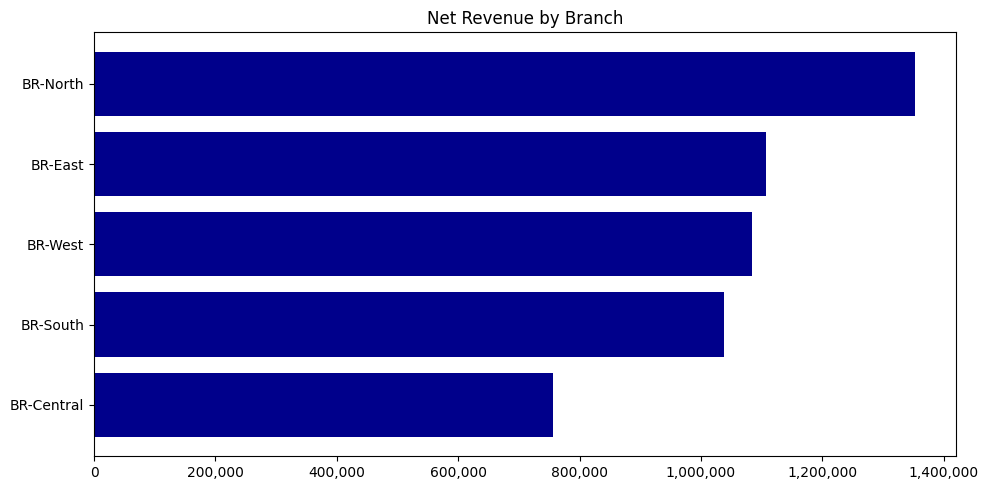

In [58]:
# --- 3.7 Branch ranking (EDA) ---
branch_summary = master.groupby("branch_id").agg(
    net_revenue=("net_revenue", "sum"),
    gross_margin=("gross_margin", "sum"),
    transactions=("transaction_id", "nunique"),
).reset_index()
branch_summary["margin_pct"] = round(100 * branch_summary["gross_margin"] / branch_summary["net_revenue"], 2)
branch_summary = branch_summary.sort_values("net_revenue", ascending=False)

print("Branch ranking:")
display(branch_summary)

fig, ax = plt.subplots()
ax.barh(branch_summary["branch_id"], branch_summary["net_revenue"], color="darkblue")
ax.invert_yaxis()
ax.set_title("Net Revenue by Branch")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()


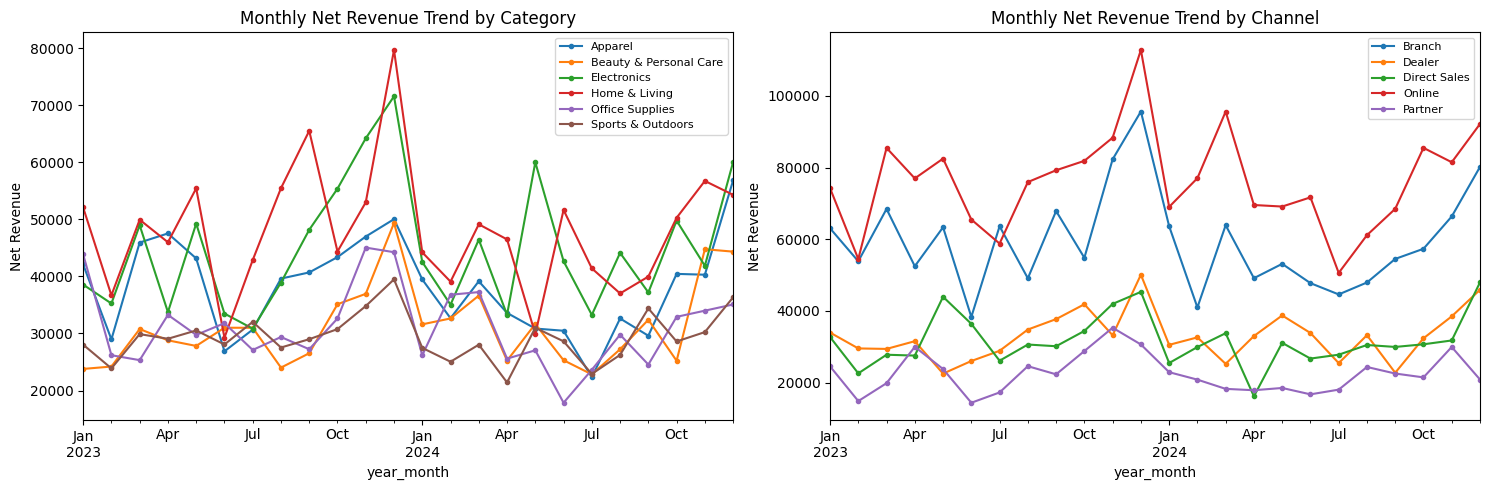

In [57]:
# --- 3.7b Trend comparison: monthly revenue by category and by channel ---
cat_trend = master.groupby(["year_month", "category"])["net_revenue"].sum().unstack(fill_value=0)
chan_trend = master.groupby(["year_month", "channel"])["net_revenue"].sum().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cat_trend.plot(ax=axes[0], marker="o", markersize=3)
axes[0].set_title("Monthly Net Revenue Trend by Category")
axes[0].set_ylabel("Net Revenue")
axes[0].legend(fontsize=8)

chan_trend.plot(ax=axes[1], marker="o", markersize=3)
axes[1].set_title("Monthly Net Revenue Trend by Channel")
axes[1].set_ylabel("Net Revenue")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [15]:
# --- 3.8 Statistical test: does mean transaction revenue differ across channels / branches? ---
# One-way ANOVA (parametric) + Kruskal-Wallis (non-parametric, robust to the right-skew
# typical of revenue data) run side by side so the more defensible test can be reported.
channel_groups = [g["net_revenue"].values for _, g in master.groupby("channel")]
branch_groups = [g["net_revenue"].values for _, g in master.groupby("branch_id")]

f_stat_ch, p_anova_ch = stats.f_oneway(*channel_groups)
h_stat_ch, p_kw_ch = stats.kruskal(*channel_groups)
print(f"Channel — ANOVA: F={f_stat_ch:.3f}, p={p_anova_ch:.5f}")
print(f"Channel — Kruskal-Wallis: H={h_stat_ch:.3f}, p={p_kw_ch:.5f}")

f_stat_br, p_anova_br = stats.f_oneway(*branch_groups)
h_stat_br, p_kw_br = stats.kruskal(*branch_groups)
print(f"\nBranch — ANOVA: F={f_stat_br:.3f}, p={p_anova_br:.5f}")
print(f"Branch — Kruskal-Wallis: H={h_stat_br:.3f}, p={p_kw_br:.5f}")


Channel — ANOVA: F=1.119, p=0.34537
Channel — Kruskal-Wallis: H=5.768, p=0.21712

Branch — ANOVA: F=0.473, p=0.75556
Branch — Kruskal-Wallis: H=1.566, p=0.81494


In [16]:
# --- 3.9 Chi-square test of independence: category vs channel ---
# Tests whether product category and sales channel are associated
# (i.e. whether certain categories are disproportionately sold through certain channels).
contingency = pd.crosstab(master["category"], master["channel"])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square = {chi2:.3f}, dof = {dof}, p-value = {p_chi:.5f}")
if p_chi < 0.05:
    print("=> Statistically significant association between category and channel.")
else:
    print("=> No statistically significant association between category and channel.")


Chi-square = 36.460, dof = 20, p-value = 0.01357
=> Statistically significant association between category and channel.


2 discontinued product(s):


,product_id,product_name,category,net_revenue,margin_pct
28,P128,Sports Rate 29,Sports & Outdoors,"25,890.21",16.83
29,P129,Office Science 30,Office Supplies,"17,076.85",19.37


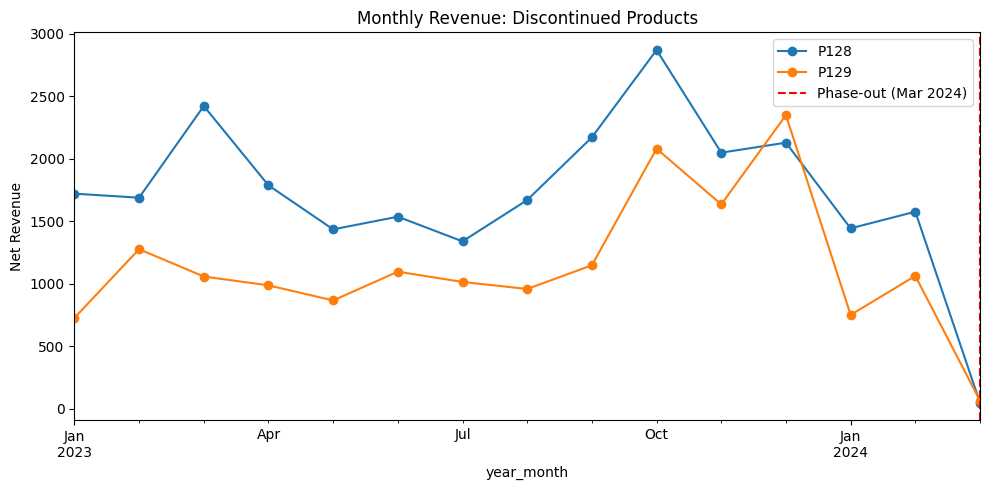

In [59]:
# --- 3.10 Discontinued product impact ---
discontinued = prod_agg[prod_agg["active_status"] == "Discontinued"]
print(f"{len(discontinued)} discontinued product(s):")
display(discontinued[["product_id", "product_name", "category", "net_revenue", "margin_pct"]])

if len(discontinued) > 0:
    disc_ids = discontinued["product_id"].tolist()
    disc_trend = (
        master[master["product_id"].isin(disc_ids)]
        .groupby(["year_month", "product_id"])["net_revenue"].sum()
        .unstack(fill_value=0)
    )

    fig, ax = plt.subplots()
    disc_trend.plot(ax=ax, marker="o")
    ax.axvline(pd.Timestamp("2024-03-31"), color="red", linestyle="--", label="Phase-out (Mar 2024)")
    ax.set_title("Monthly Revenue: Discontinued Products")
    ax.set_ylabel("Net Revenue")
    ax.legend()
    plt.tight_layout()
    plt.show()


In [60]:
# --- 3.11 Low-performing products (poor revenue AND/OR poor margin) ---
print("Bottom 5 products by revenue (weakest sellers):")
display(prod_agg.sort_values("net_revenue", ascending=True).head(5))

print("\nBottom 5 products by margin % (weakest profitability, regardless of revenue rank):")
display(prod_agg.sort_values("margin_pct", ascending=True).head(5))


Bottom 5 products by revenue (weakest sellers):


,product_id,product_name,category,active_status,net_revenue,gross_margin,units_sold,transactions,margin_pct
5,P105,Office Election 6,Office Supplies,Active,"11,456.25","3,988.30",665,427,34.81
29,P129,Office Science 30,Office Supplies,Discontinued,"17,076.85","3,307.05",569,274,19.37
21,P121,Beauty Early 22,Beauty & Personal Care,Active,"23,024.19","8,903.69",911,433,38.67
28,P128,Sports Rate 29,Sports & Outdoors,Discontinued,"25,890.21","4,358.01",510,256,16.83
3,P103,Beauty Site 4,Beauty & Personal Care,Active,"31,998.56","11,999.86",881,436,37.50



Bottom 5 products by margin % (weakest profitability, regardless of revenue rank):


,product_id,product_name,category,active_status,net_revenue,gross_margin,units_sold,transactions,margin_pct
15,P115,Beauty Performance 16,Beauty & Personal Care,Active,"234,590.55","-4,456.25",808,402,-1.90
7,P107,Home Chair 8,Home & Living,Active,"82,443.04","-1,151.34",878,437,-1.40
2,P102,Apparel Ago 3,Apparel,Active,"77,762.07",-843.03,945,473,-1.08
22,P122,Sports Mouth 23,Sports & Outdoors,Active,"107,750.52",224.28,839,433,0.21
27,P127,Beauty Sense 28,Beauty & Personal Care,Active,"278,429.18","6,067.02",973,470,2.18


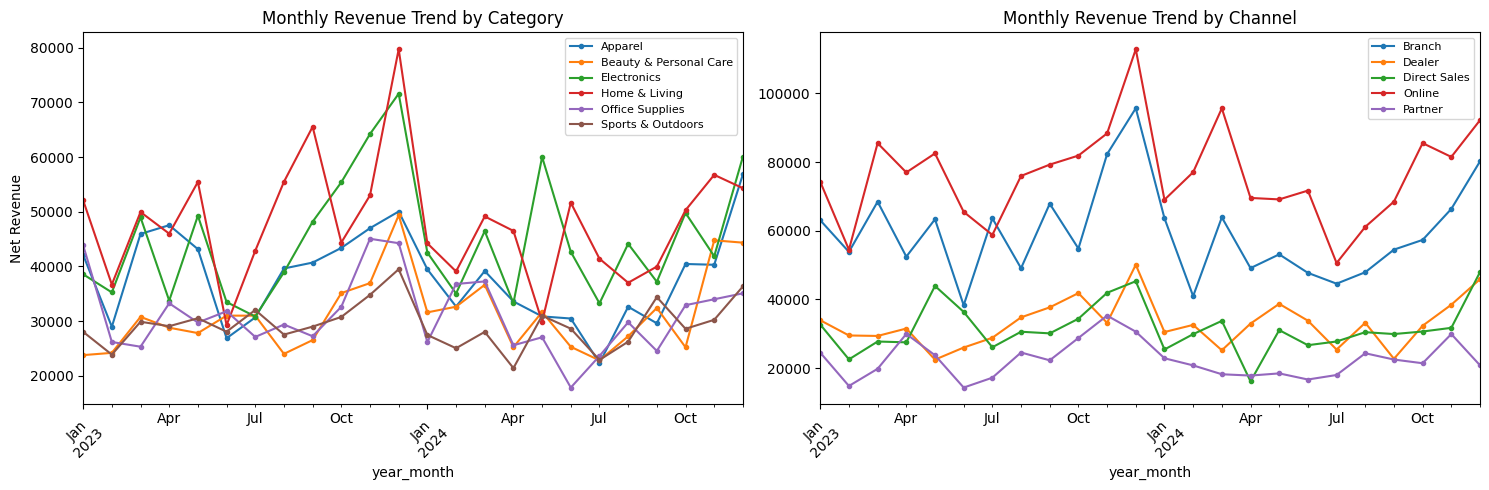

In [19]:
# --- 3.12 Trend comparison: revenue trend by category and by channel over time ---
cat_trend = master.groupby(["year_month", "category"])["net_revenue"].sum().unstack(fill_value=0)
channel_trend = master.groupby(["year_month", "channel"])["net_revenue"].sum().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cat_trend.plot(ax=axes[0], marker="o", markersize=3)
axes[0].set_title("Monthly Revenue Trend by Category")
axes[0].set_ylabel("Net Revenue")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=45)

channel_trend.plot(ax=axes[1], marker="o", markersize=3)
axes[1].set_title("Monthly Revenue Trend by Channel")
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [20]:
# --- 3.13 Channel & branch contribution % + best/weakest performer callout ---
channel_summary["revenue_contribution_pct"] = round(100 * channel_summary["net_revenue"] / channel_summary["net_revenue"].sum(), 2)
branch_summary["revenue_contribution_pct"] = round(100 * branch_summary["net_revenue"] / branch_summary["net_revenue"].sum(), 2)

best_channel = channel_summary.sort_values("net_revenue", ascending=False).iloc[0]
weakest_channel_by_margin = channel_summary.sort_values("margin_pct", ascending=True).iloc[0]
best_branch = branch_summary.sort_values("net_revenue", ascending=False).iloc[0]
weakest_branch = branch_summary.sort_values("net_revenue", ascending=True).iloc[0]

print(f"Best performing channel by revenue: {best_channel['channel']} "
      f"({best_channel['revenue_contribution_pct']}% of total revenue, {best_channel['margin_pct']}% margin)")
print(f"Weakest performing channel by margin: {weakest_channel_by_margin['channel']} "
      f"({weakest_channel_by_margin['margin_pct']}% margin)")
print(f"\nBest performing branch by revenue: {best_branch['branch_id']} "
      f"({best_branch['revenue_contribution_pct']}% of total revenue)")
print(f"Weakest performing branch by revenue: {weakest_branch['branch_id']} "
      f"({weakest_branch['revenue_contribution_pct']}% of total revenue)")

display(channel_summary[["channel", "net_revenue", "revenue_contribution_pct", "margin_pct"]])
display(branch_summary[["branch_id", "net_revenue", "revenue_contribution_pct", "margin_pct"]])


Best performing channel by revenue: Online (34.23% of total revenue, 22.17% margin)
Weakest performing channel by margin: Dealer (21.94% margin)

Best performing branch by revenue: BR-North (25.35% of total revenue)
Weakest performing branch by revenue: BR-Central (14.17% of total revenue)


,channel,net_revenue,revenue_contribution_pct,margin_pct
3,Online,"1,827,676.97",34.23,22.17
0,Branch,"1,422,183.82",26.63,22.98
1,Dealer,"791,132.55",14.82,21.94
2,Direct Sales,"760,757.73",14.25,22.40
4,Partner,"537,868.47",10.07,22.54


,branch_id,net_revenue,revenue_contribution_pct,margin_pct
2,BR-North,"1,353,483.71",25.35,22.36
1,BR-East,"1,107,221.67",20.74,22.53
4,BR-West,"1,083,634.69",20.29,22.93
3,BR-South,"1,038,678.58",19.45,21.98
0,BR-Central,"756,600.89",14.17,22.25


## Module 4 — Pricing and Discount Analysis

Discount % — descriptive statistics:


,discount_percentage
count,"12,922.00"
mean,6.68
std,7.63
min,0.00
25%,0.00
50%,5.00
75%,10.00
max,30.00


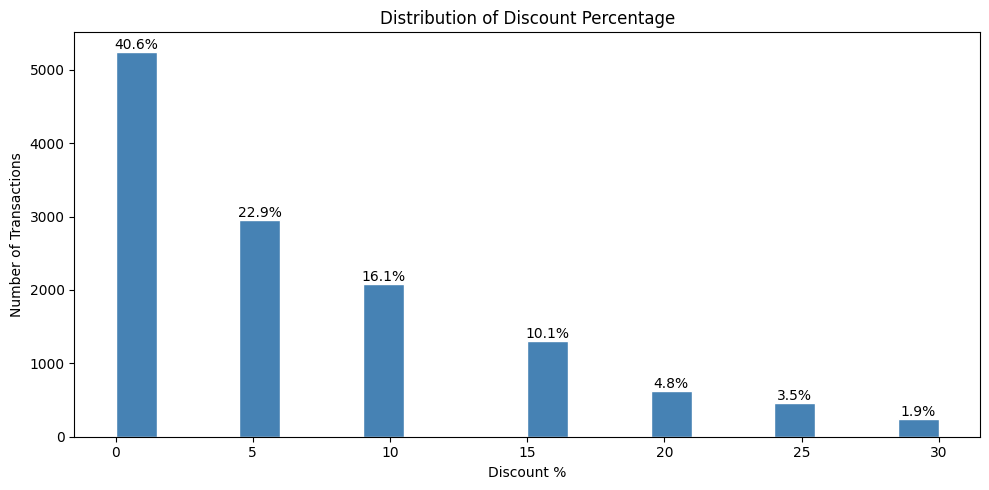

In [42]:
# --- 4.1 Discount distribution (EDA) ---
print("Discount % — descriptive statistics:")
display(master["discount_percentage"].describe())

fig, ax = plt.subplots()
n, bins, patches = ax.hist(master["discount_percentage"], bins=20, color="steelblue", edgecolor="white")
ax.set_title("Distribution of Discount Percentage")
ax.set_xlabel("Discount %")
ax.set_ylabel("Number of Transactions")

total_transactions = len(master)

# Add percentages on top of each bar
for i in range(len(n)):
    height = n[i]
    percentage = (height / total_transactions) * 100
    if percentage > 0.5:  # Only display for bars with a significant percentage
        ax.text(bins[i] + (bins[i+1] - bins[i]) / 2, height, f'{percentage:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Revenue and margin by discount band:


,discount_band,net_revenue,gross_margin,transactions,avg_quantity,margin_pct
0,0%,"2,325,452.11","622,084.27",5249,2.03,26.75
1,1-5%,"1,279,215.02","301,197.82",2960,2.04,23.55
2,6-10%,"847,848.70","164,833.00",2085,2.05,19.44
3,11-15%,"530,840.05","80,384.13",1308,2.05,15.14
4,16-20%,"197,893.50","22,256.13",623,1.82,11.25
5,21-25%,"118,033.16","4,705.62",453,1.65,3.99
6,26%+,"40,337.00","1,810.74",244,1.28,4.49


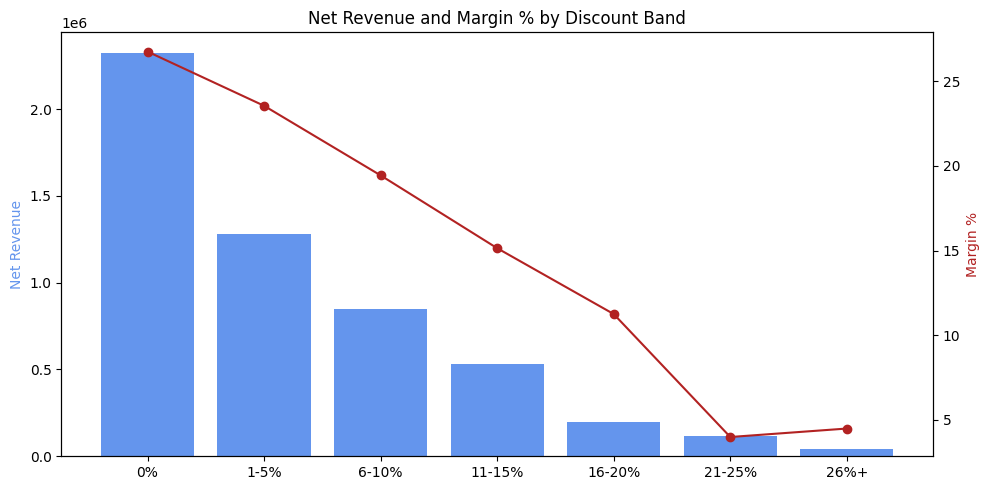

In [22]:
# --- 4.2 Revenue and margin by discount band (EDA) ---
bins = [-0.1, 0, 5, 10, 15, 20, 25, 100]
labels = ["0%", "1-5%", "6-10%", "11-15%", "16-20%", "21-25%", "26%+"]
master["discount_band"] = pd.cut(master["discount_percentage"], bins=bins, labels=labels)

band_summary = master.groupby("discount_band", observed=True).agg(
    net_revenue=("net_revenue", "sum"),
    gross_margin=("gross_margin", "sum"),
    transactions=("transaction_id", "nunique"),
    avg_quantity=("quantity", "mean"),
).reset_index()
band_summary["margin_pct"] = round(100 * band_summary["gross_margin"] / band_summary["net_revenue"], 2)

print("Revenue and margin by discount band:")
display(band_summary)

fig, ax1 = plt.subplots()
ax1.bar(band_summary["discount_band"], band_summary["net_revenue"], color="cornflowerblue", label="Net Revenue")
ax1.set_ylabel("Net Revenue", color="cornflowerblue")

ax2 = ax1.twinx()
ax2.plot(band_summary["discount_band"], band_summary["margin_pct"], color="firebrick", marker="o", label="Margin %")
ax2.set_ylabel("Margin %", color="firebrick")

plt.title("Net Revenue and Margin % by Discount Band")
plt.tight_layout()
plt.show()


Pearson correlation (discount vs margin): r=-0.364, p=0.00000
Spearman correlation (discount vs margin): rho=-0.348, p=0.00000


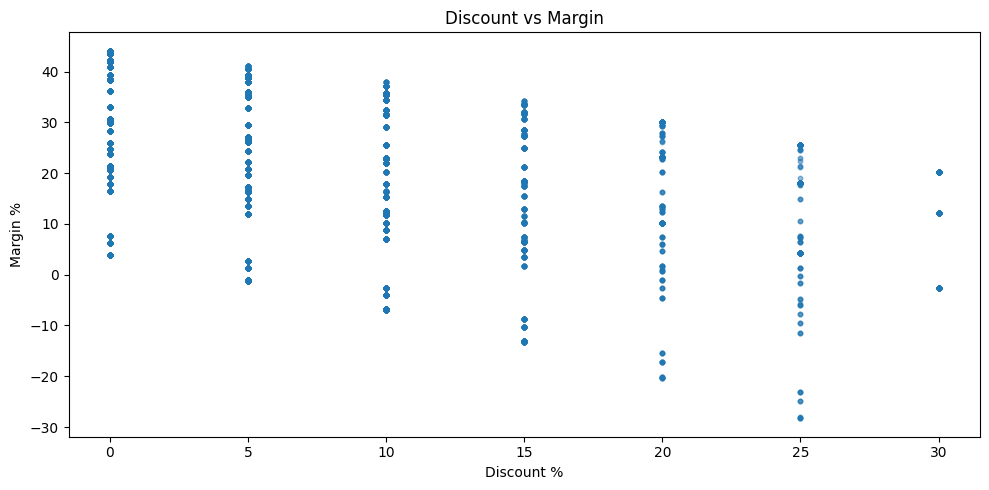

In [44]:
# --- 4.3 Discount % vs margin % correlation (statistical) ---
pearson_corr, pearson_p = stats.pearsonr(master["discount_percentage"], master["margin_pct"])
spearman_corr, spearman_p = stats.spearmanr(master["discount_percentage"], master["margin_pct"])

print(f"Pearson correlation (discount vs margin): r={pearson_corr:.3f}, p={pearson_p:.5f}")
print(f"Spearman correlation (discount vs margin): rho={spearman_corr:.3f}, p={spearman_p:.5f}")

fig, ax = plt.subplots()
ax.scatter(master["discount_percentage"], master["margin_pct"], alpha=0.15, s=10)
ax.set_xlabel("Discount %")
ax.set_ylabel("Margin %")
ax.set_title("Discount vs Margin")
plt.tight_layout()
plt.show()


In [24]:
# --- 4.4 Regression: does discount actually move volume or revenue? ---
# quantity ~ discount_percentage
X = sm.add_constant(master["discount_percentage"])
qty_model = sm.OLS(master["quantity"], X).fit()
print("OLS: quantity ~ discount_percentage")
print(qty_model.summary())

# net_revenue ~ discount_percentage
rev_model = sm.OLS(master["net_revenue"], X).fit()
print("\nOLS: net_revenue ~ discount_percentage")
print(rev_model.summary())


OLS: quantity ~ discount_percentage
                            OLS Regression Results                            
Dep. Variable:               quantity   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     78.08
Date:                Fri, 31 Jul 2026   Prob (F-statistic):           1.12e-18
Time:                        04:18:11   Log-Likelihood:                -20500.
No. Observations:               12922   AIC:                         4.100e+04
Df Residuals:                   12920   BIC:                         4.102e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

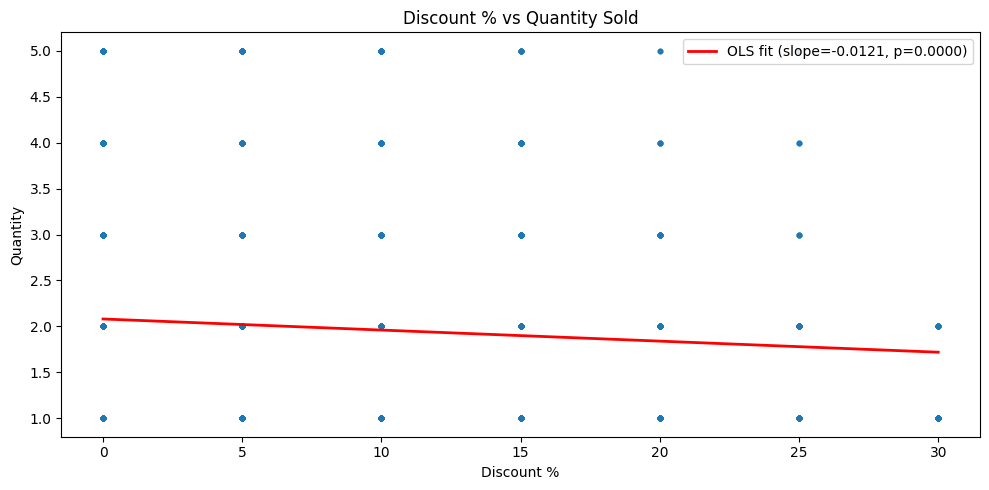

In [25]:
# --- 4.5 Visualize the discount -> quantity regression ---
fig, ax = plt.subplots()
ax.scatter(master["discount_percentage"], master["quantity"], alpha=0.1, s=10)

x_range = np.linspace(master["discount_percentage"].min(), master["discount_percentage"].max(), 100)
y_pred = qty_model.params["const"] + qty_model.params["discount_percentage"] * x_range
ax.plot(x_range, y_pred, color="red", linewidth=2, label=f"OLS fit (slope={qty_model.params['discount_percentage']:.4f}, p={qty_model.pvalues['discount_percentage']:.4f})")

ax.set_xlabel("Discount %")
ax.set_ylabel("Quantity")
ax.set_title("Discount % vs Quantity Sold")
ax.legend()
plt.tight_layout()
plt.show()


In [26]:
# --- 4.6 Over-discounted products: high discount with no corresponding volume lift ---
# Per-product correlation between discount % and quantity. Products with a heavy average
# discount but a flat/negative correlation are giving away margin without buying extra volume.
results = []
for pid, grp in master.groupby("product_id"):
    if grp["discount_percentage"].nunique() < 2 or len(grp) < 10:
        continue
    corr, p_val = stats.pearsonr(grp["discount_percentage"], grp["quantity"])
    results.append({
        "product_id": pid,
        "avg_discount_pct": round(grp["discount_percentage"].mean(), 2),
        "avg_quantity": round(grp["quantity"].mean(), 2),
        "n_transactions": len(grp),
        "discount_qty_corr": round(corr, 3),
        "p_value": round(p_val, 4),
    })

discount_corr_df = pd.DataFrame(results)

over_discounted = discount_corr_df[
    (discount_corr_df["avg_discount_pct"] >= 15) &
    ((discount_corr_df["discount_qty_corr"] <= 0.05) | (discount_corr_df["p_value"] >= 0.05))
].sort_values("avg_discount_pct", ascending=False)

print(f"{len(over_discounted)} product(s) flagged as over-discounted (heavy discount, no significant volume lift):")
display(over_discounted.merge(products[["product_id", "product_name", "category"]], on="product_id", how="left"))


2 product(s) flagged as over-discounted (heavy discount, no significant volume lift):


,product_id,avg_discount_pct,avg_quantity,n_transactions,discount_qty_corr,p_value,product_name,category
0,P105,16.45,1.56,427,-0.34,0.00,Office Election 6,Office Supplies
1,P112,15.17,1.70,462,-0.30,0.00,Electronics Wait 13,Electronics


In [27]:
# --- 4.6b Over-discounted customers ---
# Customers receiving deep average discounts without a corresponding revenue/frequency payoff.
customer_disc = master.groupby("customer_id").agg(
    avg_discount_pct=("discount_percentage", "mean"),
    total_net_revenue=("net_revenue", "sum"),
    transactions=("transaction_id", "nunique"),
).reset_index()

discount_p75 = customer_disc["avg_discount_pct"].quantile(0.75)
revenue_median_cust = customer_disc["total_net_revenue"].median()

over_discounted_customers = customer_disc[
    (customer_disc["avg_discount_pct"] >= discount_p75) &
    (customer_disc["total_net_revenue"] <= revenue_median_cust)
].sort_values("avg_discount_pct", ascending=False)

print(f"{len(over_discounted_customers)} customer(s) flagged as over-discounted "
      f"(top-quartile avg discount, below-median total revenue):")
display(over_discounted_customers.merge(
    customers[["customer_id", "customer_type", "segment"]], on="customer_id", how="left"
).head(15))


18 customer(s) flagged as over-discounted (top-quartile avg discount, below-median total revenue):


,customer_id,avg_discount_pct,total_net_revenue,transactions,customer_type,segment
0,C1031,8.40,"39,400.51",94,SME,Budget
1,C1104,8.13,"42,153.65",107,Individual,Standard
2,C1111,7.88,"37,794.86",99,Individual,Premium
3,C1054,7.80,"32,935.62",91,SME,Standard
4,C1027,7.69,"41,439.76",106,SME,Budget
5,C1095,7.67,"39,153.88",88,Individual,Standard
6,C1002,7.64,"44,703.06",108,SME,New
7,C1113,7.55,"44,096.91",102,Individual,Standard
8,C1064,7.53,"36,067.70",79,Individual,Premium
9,C1110,7.50,"36,153.74",96,SME,Premium


In [28]:
# --- 4.7 Discount behavior inside vs outside active campaign windows ---
# Confirms/refutes the assumption that discounting is heavier while a campaign is running.
campaign_starts = campaigns["start_date"].values
campaign_ends = campaigns["end_date"].values

def matched_campaign(date):
    hits = campaigns[(campaigns["start_date"] <= date) & (date <= campaigns["end_date"])]
    return hits.iloc[0]["campaign_id"] if len(hits) else None

master["campaign_id"] = master["transaction_date"].apply(matched_campaign)
master["in_campaign"] = master["campaign_id"].notna()

in_camp = master.loc[master["in_campaign"], "discount_percentage"]
out_camp = master.loc[~master["in_campaign"], "discount_percentage"]

t_stat, p_ttest = stats.ttest_ind(in_camp, out_camp, equal_var=False)
u_stat, p_mwu = stats.mannwhitneyu(in_camp, out_camp, alternative="two-sided")

print(f"Avg discount % during campaigns: {in_camp.mean():.2f}%  (n={len(in_camp)})")
print(f"Avg discount % outside campaigns: {out_camp.mean():.2f}%  (n={len(out_camp)})")
print(f"\nWelch t-test: t={t_stat:.3f}, p={p_ttest:.5f}")
print(f"Mann-Whitney U: U={u_stat:.1f}, p={p_mwu:.5f}")


Avg discount % during campaigns: 13.64%  (n=2939)
Avg discount % outside campaigns: 4.64%  (n=9983)

Welch t-test: t=65.472, p=0.00000
Mann-Whitney U: U=24984415.5, p=0.00000


In [29]:
# --- 4.8 Campaign ROI: revenue generated during each campaign window vs its cost ---
campaign_roi = master[master["in_campaign"]].groupby("campaign_id").agg(
    net_revenue=("net_revenue", "sum"),
    gross_margin=("gross_margin", "sum"),
    transactions=("transaction_id", "nunique"),
).reset_index()

campaign_roi = campaign_roi.merge(campaigns[["campaign_id", "campaign_name", "offer_type", "campaign_cost"]], on="campaign_id", how="left")
campaign_roi["roi"] = round((campaign_roi["gross_margin"] - campaign_roi["campaign_cost"]) / campaign_roi["campaign_cost"], 2)
campaign_roi = campaign_roi.sort_values("roi", ascending=False)

print("Campaign ROI (using gross margin generated during the campaign window vs campaign cost):")
display(campaign_roi[["campaign_id", "campaign_name", "offer_type", "net_revenue", "gross_margin", "campaign_cost", "roi"]])


Campaign ROI (using gross margin generated during the campaign window vs campaign cost):


,campaign_id,campaign_name,offer_type,net_revenue,gross_margin,campaign_cost,roi
3,CMP004,Back to School,Discount,"119,583.83","20,731.02",7000,1.96
0,CMP001,New Year Kickoff,Seasonal Offer,"121,207.54","21,544.27",8000,1.69
2,CMP003,Mid-Year Clearance,Discount,"88,802.02","15,259.26",6000,1.54
4,CMP005,Festive Cashback,Cashback,"145,819.93","24,481.01",12000,1.04
5,CMP006,Year End Blowout,Seasonal Offer,"181,442.67","29,905.11",15000,0.99
6,CMP007,New Year Kickoff 2024,Seasonal Offer,"100,432.31","16,509.93",9000,0.83
8,CMP009,Festive Cashback 2024,Cashback,"146,253.00","23,005.82",13000,0.77
9,CMP010,Year End Blowout 2024,Seasonal Offer,"152,830.22","26,176.63",16000,0.64
7,CMP008,Anniversary Sale,Discount,"55,990.84","9,746.80",6500,0.50
1,CMP002,Valentine Bundle,Bundle,"49,688.11","7,249.33",5000,0.45


In [30]:
# --- 4.9 Does discount % differ significantly by customer segment / type? ---
segment_groups = [g["discount_percentage"].values for _, g in master.groupby("segment")]
f_stat_seg, p_seg = stats.f_oneway(*segment_groups)
h_stat_seg, p_seg_kw = stats.kruskal(*segment_groups)

print(f"Discount % by segment — ANOVA: F={f_stat_seg:.3f}, p={p_seg:.5f}")
print(f"Discount % by segment — Kruskal-Wallis: H={h_stat_seg:.3f}, p={p_seg_kw:.5f}")

seg_discount_summary = master.groupby("segment")["discount_percentage"].agg(["mean", "median", "std", "count"]).round(2)
display(seg_discount_summary)

type_groups = [g["discount_percentage"].values for _, g in master.groupby("customer_type")]
f_stat_type, p_type = stats.f_oneway(*type_groups)
print(f"\nDiscount % by customer_type — ANOVA: F={f_stat_type:.3f}, p={p_type:.5f}")


Discount % by segment — ANOVA: F=2.731, p=0.04222
Discount % by segment — Kruskal-Wallis: H=9.339, p=0.02510


,mean,median,std,count
segment,,,,
Budget,6.50,5.00,7.60,3590
New,6.85,5.00,7.87,2557
Premium,7.06,5.00,7.66,1780
Standard,6.60,5.00,7.50,4995



Discount % by customer_type — ANOVA: F=1.570, p=0.20803


,campaign_id,campaign_name,duration_days,avg_daily_revenue_before,avg_daily_revenue_during,avg_discount_before,avg_discount_during,revenue_uplift_pct
0,CMP001,New Year Kickoff,16,"1,579.44","7,575.47",4.85,13.83,379.60
1,CMP002,Valentine Bundle,9,"6,311.89","5,520.90",5.50,14.13,-12.50
2,CMP003,Mid-Year Clearance,15,"8,131.99","5,920.13",4.23,13.17,-27.20
3,CMP004,Back to School,17,"6,681.31","7,034.34",4.52,13.76,5.30
4,CMP005,Festive Cashback,16,"8,994.69","9,113.75",4.52,12.85,1.30
5,CMP006,Year End Blowout,17,"10,471.78","10,673.10",7.26,14.15,1.90
6,CMP007,New Year Kickoff 2024,16,"10,214.22","6,277.02",12.20,13.53,-38.50
7,CMP008,Anniversary Sale,10,"7,505.46","5,599.08",4.30,13.14,-25.40
8,CMP009,Festive Cashback 2024,16,"8,414.00","9,140.81",4.45,14.35,8.60
9,CMP010,Year End Blowout 2024,17,"9,382.35","8,990.01",9.64,13.26,-4.20



Wilcoxon signed-rank (daily revenue, before vs during): W=21.000, p=0.55664


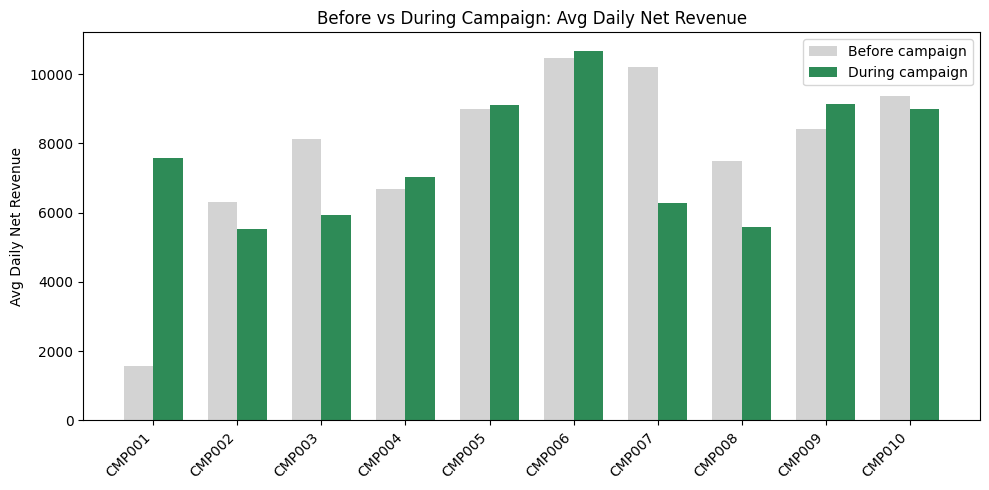

In [31]:
# --- 4.9b Before-and-after promotion analysis ---
# For each campaign, compare average daily net revenue and discount % in the campaign
# window against an equal-length baseline window immediately BEFORE it started.
rows = []
for _, camp in campaigns.iterrows():
    duration = (camp["end_date"] - camp["start_date"]).days + 1
    pre_start = camp["start_date"] - pd.Timedelta(days=duration)
    pre_end = camp["start_date"] - pd.Timedelta(days=1)

    during = master[(master["transaction_date"] >= camp["start_date"]) & (master["transaction_date"] <= camp["end_date"])]
    before = master[(master["transaction_date"] >= pre_start) & (master["transaction_date"] <= pre_end)]

    rows.append({
        "campaign_id": camp["campaign_id"],
        "campaign_name": camp["campaign_name"],
        "duration_days": duration,
        "avg_daily_revenue_before": round(before["net_revenue"].sum() / duration, 2),
        "avg_daily_revenue_during": round(during["net_revenue"].sum() / duration, 2),
        "avg_discount_before": round(before["discount_percentage"].mean(), 2) if len(before) else np.nan,
        "avg_discount_during": round(during["discount_percentage"].mean(), 2) if len(during) else np.nan,
    })

before_after = pd.DataFrame(rows)
before_after["revenue_uplift_pct"] = round(
    100 * (before_after["avg_daily_revenue_during"] - before_after["avg_daily_revenue_before"])
    / before_after["avg_daily_revenue_before"], 1
)
display(before_after)

# Paired test (n=10 campaigns, so Wilcoxon signed-rank is more appropriate than a t-test)
w_stat, p_wilcoxon = stats.wilcoxon(before_after["avg_daily_revenue_before"], before_after["avg_daily_revenue_during"])
print(f"\nWilcoxon signed-rank (daily revenue, before vs during): W={w_stat:.3f}, p={p_wilcoxon:.5f}")

fig, ax = plt.subplots()
x = np.arange(len(before_after))
width = 0.35
ax.bar(x - width/2, before_after["avg_daily_revenue_before"], width, label="Before campaign", color="lightgray")
ax.bar(x + width/2, before_after["avg_daily_revenue_during"], width, label="During campaign", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(before_after["campaign_id"], rotation=45, ha="right")
ax.set_ylabel("Avg Daily Net Revenue")
ax.set_title("Before vs During Campaign: Avg Daily Net Revenue")
ax.legend()
plt.tight_layout()
plt.show()


In [45]:
# --- 4.11 Over-discounted customers: heavy avg discount received with no extra spend benefit ---
cust_disc = master.groupby("customer_id").agg(
    avg_discount_pct=("discount_percentage", "mean"),
    total_net_revenue=("net_revenue", "sum"),
    transactions=("transaction_id", "nunique"),
).reset_index()

disc_threshold = cust_disc["avg_discount_pct"].quantile(0.75)
heavy_discount_custs = cust_disc[cust_disc["avg_discount_pct"] >= disc_threshold].sort_values("avg_discount_pct", ascending=False)

print(f"{len(heavy_discount_custs)} customers sit in the top quartile of average discount received (>= {disc_threshold:.2f}%):")
display(heavy_discount_custs.merge(customers[["customer_id", "customer_type", "segment"]], on="customer_id", how="left").head(15))

rest = cust_disc[~cust_disc["customer_id"].isin(heavy_discount_custs["customer_id"])]
print("\nSpend comparison: heavy-discount customers vs everyone else:")
print(f"  Heavy-discount group — avg total revenue per customer: {heavy_discount_custs['total_net_revenue'].mean():,.2f}, avg transactions: {heavy_discount_custs['transactions'].mean():.1f}")
print(f"  Remaining customers  — avg total revenue per customer: {rest['total_net_revenue'].mean():,.2f}, avg transactions: {rest['transactions'].mean():.1f}")


30 customers sit in the top quartile of average discount received (>= 7.15%):


,customer_id,avg_discount_pct,total_net_revenue,transactions,customer_type,segment
0,C1031,8.40,"39,400.51",94,SME,Budget
1,C1104,8.13,"42,153.65",107,Individual,Standard
2,C1025,8.13,"47,898.00",115,Individual,Premium
3,C1011,7.89,"49,591.68",128,Individual,New
4,C1111,7.88,"37,794.86",99,Individual,Premium
5,C1054,7.80,"32,935.62",91,SME,Standard
6,C1027,7.69,"41,439.76",106,SME,Budget
7,C1095,7.67,"39,153.88",88,Individual,Standard
8,C1042,7.65,"49,310.25",119,Individual,Premium
9,C1002,7.64,"44,703.06",108,SME,New



Spend comparison: heavy-discount customers vs everyone else:
  Heavy-discount group — avg total revenue per customer: 44,367.78, avg transactions: 107.3
  Remaining customers  — avg total revenue per customer: 44,539.84, avg transactions: 107.8


,campaign_id,campaign_name,avg_daily_revenue_before,avg_daily_revenue_during,avg_daily_revenue_after,lift_during_vs_before_pct
0,CMP001,New Year Kickoff,"6,317.78","7,575.47","6,477.08",19.90
1,CMP002,Valentine Bundle,"6,765.44","5,520.90","7,570.56",-18.40
2,CMP003,Mid-Year Clearance,"7,798.43","5,920.13","6,140.16",-24.10
3,CMP004,Back to School,"6,814.06","7,034.34","7,978.55",3.20
4,CMP005,Festive Cashback,"9,087.88","9,113.75","11,315.04",0.30
5,CMP006,Year End Blowout,"10,932.30","10,673.10","6,506.61",-2.40
6,CMP007,New Year Kickoff 2024,"10,275.55","6,277.02","7,306.89",-38.90
7,CMP008,Anniversary Sale,"7,903.90","5,599.08","6,333.25",-29.20
8,CMP009,Festive Cashback 2024,"8,562.12","9,140.81","9,039.79",6.80
9,CMP010,Year End Blowout 2024,"9,586.34","8,990.01",NaN,-6.20


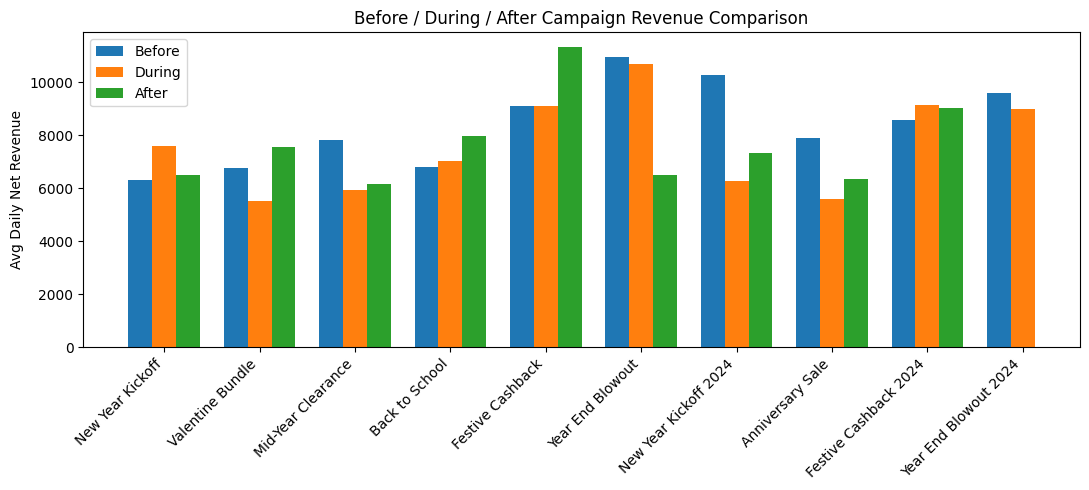

In [34]:
# --- 4.12 Before-and-after promotion analysis ---
window_days = 14
daily_rev = master.groupby("transaction_date")["net_revenue"].sum()

rows = []
for _, camp in campaigns.iterrows():
    before_start = camp["start_date"] - pd.Timedelta(days=window_days)
    after_end = camp["end_date"] + pd.Timedelta(days=window_days)

    before = daily_rev[(daily_rev.index >= before_start) & (daily_rev.index < camp["start_date"])]
    during = daily_rev[(daily_rev.index >= camp["start_date"]) & (daily_rev.index <= camp["end_date"])]
    after = daily_rev[(daily_rev.index > camp["end_date"]) & (daily_rev.index <= after_end)]

    rows.append({
        "campaign_id": camp["campaign_id"],
        "campaign_name": camp["campaign_name"],
        "avg_daily_revenue_before": round(before.mean(), 2) if len(before) else np.nan,
        "avg_daily_revenue_during": round(during.mean(), 2) if len(during) else np.nan,
        "avg_daily_revenue_after": round(after.mean(), 2) if len(after) else np.nan,
    })

before_after = pd.DataFrame(rows)
before_after["lift_during_vs_before_pct"] = round(
    100 * (before_after["avg_daily_revenue_during"] - before_after["avg_daily_revenue_before"]) / before_after["avg_daily_revenue_before"], 1
)
display(before_after)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(before_after))
width = 0.25
ax.bar(x - width, before_after["avg_daily_revenue_before"], width, label="Before")
ax.bar(x, before_after["avg_daily_revenue_during"], width, label="During")
ax.bar(x + width, before_after["avg_daily_revenue_after"], width, label="After")
ax.set_xticks(x)
ax.set_xticklabels(before_after["campaign_name"], rotation=45, ha="right")
ax.set_ylabel("Avg Daily Net Revenue")
ax.set_title("Before / During / After Campaign Revenue Comparison")
ax.legend()
plt.tight_layout()
plt.show()
